In [2]:
%load_ext autoreload
import os
import pickle
import sys
from datetime import datetime
from ipywidgets import widgets
from matplotlib.lines import Line2D
from ptflops import get_model_complexity_info
from torch.optim import Adam
from tqdm import tqdm

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
%autoreload 2
from src import *

plt.rcParams.update({'font.size': 20})

In [5]:
df_x, df_y = read_dataset(stage='original')
# df_x['np/ng'] = df_x['np'] / df_x['ng']
df_x.drop(inplace=True, columns=['ias', 'oat'])
df_x['trq_margin'] = df_y['trq_margin']
df_x['domain'] = (df_x['np'] / df_x['ng'] < 1).astype(int) + 1

In [7]:
def get_title(model, domains, epochs, times, lr, is_file=False):
    additional = f'grid={model.grid_size}' if type(model) in [PyKAN, EfficientKAN] else ''
    return f'{model.__class__.__name__}_layers=[{"-".join(map(str, model.layers))}]_epochs={epochs}_times={times}_lr={lr}_{additional}_{datetime.now().ctime().replace(":", "-")}' if is_file else f'{model.__class__.__name__} Epochs={epochs} Times={times} Lr={lr}'

In [8]:
def plot(losses: tuple[list, list, list], train=False, valid=False, title=None, scale=1, ax=None,
         standalone=True, label=None, metric='test_loss', ylim=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(20 * scale, 10 * scale))
        ax.set_xticks(range(0, len(losses[0]) * len(losses[0][0]) + 1, len(losses[0][0])))
        for i, test_loss in enumerate(losses[0]):
            ax.add_line(
                Line2D([(i + 1) * len(test_loss)] * 2, [0, 99], linestyle='--', color='black', linewidth=1, alpha=0.5))
            ax.fill_between(range(i * len(test_loss), (i + 1) * len(test_loss) + 1), -99, 99, alpha=0.25,
                            color='tab:green' if i % 2 == 0 else 'tab:red',
                            label=None if i > 1 else 'np > ng' if i % 2 == 0 else 'np < ng')
        ax.set_ylim(ylim if ylim else [-1, 0] if min(losses[0][-1]) < 0 else [0, 2])
        ax.set_xlabel('Epoch')
        ax.set_ylabel(' '.join(map(lambda s: s.capitalize(), metric.split('_'))))
    if train:
        ax.plot([x for xs in losses[0] for x in xs], color='tab:orange', label='train')
    if valid:
        ax.plot([x for xs in losses[1] for x in xs], color='tab:green', label='valid')
    ax.plot([x[metric] for xs in losses[2] for x in xs], color='tab:blue' if standalone else None,
            label='test' if label is None else label, linewidth=3)

    if title: ax.set_title(title)
    if standalone:
        ax.legend()
        plt.show()
    return ax

In [9]:
def idl_train(model: PHMNetwork, domains: list[int], epochs: int, times: int, lr=1e-3, device='cpu', silent=True) -> \
        tuple[
            list, list, list]:
    model.reset()
    train_losses, valid_losses, test_metrics = [], [], []
    optimizer = Adam(model.parameters(), lr=lr)
    trainset, validset, testset, _ = split_dataset(df_x, df_y['faulty'], 0.5, standardize_y=False,
                                                   group_by='domain', device=device, seed=0)
    for i, domain in enumerate(tqdm(domains * times)):
        min_length = min(trainset[1][0].shape[0], trainset[2][0].shape[0])
        for d in domains:
            trainset[d] = (trainset[d][0][:min_length], trainset[d][1][:min_length])

        def test():
            metrics = model.test(testset, batch_size=2048, silent=silent)
            test_metrics[i].append(metrics)

        test_metrics.append([])
        train_loss, valid_loss = (
            model.fit(trainset[domain], validset[domain], optimizer, epochs=epochs,
                      batch_size=2048, callback=test, silent=silent))
        train_losses.append(train_loss)
        valid_losses.append(valid_loss)
        # model.save(f'IDL_{model.__class__.__name__}_{domain}')

    # Plot graph
    plot((train_losses, valid_losses, test_metrics), title=get_title(model, domains, epochs, times, lr), metric='avg_test_score')

    # Save to file
    with open(f'results/{get_title(model, domains, epochs, times, lr, is_file=True)}', 'wb') as f:
        pickle.dump((train_losses, valid_losses, test_metrics), f)
    return train_losses, valid_losses, test_metrics

In [10]:
def visualizer_gui(metric='test_loss', ylim=None, title=None, loc='best'):
    output = widgets.Output()
    selected_files = []
    buttons = {}
    losses = {}
    last_ax = {'ax': None}

    def select_file(file, deselect_all=False):
        with output:
            try:
                output.clear_output()
                if deselect_all:
                    selected_files.clear()
                else:
                    if file in selected_files:
                        selected_files.remove(file)
                    else:
                        selected_files.append(file)

                # Set button styles
                for f, button in buttons.items():
                    button.button_style = 'primary' if f in selected_files else ''

                # Plot
                ax = None

                def format_label(file):
                    pieces = file.replace('_layers=', '').replace('EfficientKAN', 'KAN').split('_')[:-1]
                    pieces = filter(lambda piece: not any(x in piece for x in ['epoch', 'times']) and len(piece) > 1,
                                    pieces)
                    return ', '.join(pieces)

                for selected_file in selected_files:
                    ax = plot(losses[selected_file], title=title if title else file, train=False, ax=ax,
                              standalone=False, label=format_label(selected_file), metric=metric, ylim=ylim)
                if ax:
                    ax.legend(loc=loc)
                    last_ax['ax'] = ax
                    plt.show()
                save.layout.display = 'block' if ax else 'none'
            except Exception as e:
                print(e)

    def save_fig():
        if last_ax['ax'] is not None:
            fig = last_ax['ax'].get_figure()
            filename = f"{last_ax['ax'].get_title() or 'plot'}.png"
            fig.savefig(f'img/{filename}', dpi=300, bbox_inches='tight')

    files = os.listdir('results/')
    files = sorted(files, key=lambda f: os.path.getctime(os.path.join('results/', f)), reverse=False)

    for file in files:
        if os.path.isdir(f'results/{file}'):
            continue
        with open(f'results/{file}', 'rb') as f:
            losses[file] = pickle.load(f)

        btn = widgets.Button(
            description=' ——— '.join(file.split('_')[:-1]),
            layout=widgets.Layout(width='auto'),
            style={'font_size': '20px', 'text_decoration': 'underline' if min(losses[file][0][-1]) < 0 else ''},
            button_style='',
        )
        btn.on_click(lambda _, f=file: select_file(f))
        buttons[file] = btn
    clear = widgets.Button(
        description='✖️ Clear',
        layout=widgets.Layout(width='auto'),
        style={'font_size': '20px', 'font_weight': ''},
        button_style='warning',
    )
    clear.on_click(lambda _: select_file(None, deselect_all=True))
    save = widgets.Button(
        description='💾 Save Plot',
        layout=widgets.Layout(width='auto'),
        style={'font_size': '20px', 'font_weight': ''},
        button_style='success',
    )
    save.layout.display = 'none'
    save.on_click(lambda _: save_fig())
    spacer = widgets.HTML(value="<div style='margin-top:30px;'></div>")
    display(widgets.VBox([*buttons.values(), clear, spacer, output, save]))

In [4]:
USE_NATIVE_LOSS = True
DOMAINS = [1, 2]
EPOCHS = 5
TIMES = 8
LR = 2e-2

## Finding a matching shape for KAN and MLP with `ptflops`

In [3]:
effKAN = EfficientKAN([len(df_x.columns) - 1, 51, 51, 1], 'classification', grid_size=20, continual_learning=True)
mlp = MLP([len(df_x.columns) - 1, 256, 256, 1], 'classification')

for net in [effKAN, mlp]:
    flops, params = get_model_complexity_info(net, (len(df_x.columns) - 1,), as_strings=True,
                                              print_per_layer_stat=False)
    print(f"[{net.__class__.__name__}] FLOPs: {flops} | Params: {params}")

NameError: name 'df_x' is not defined

# KAN

100%|██████████| 2/2 [04:32<00:00, 136.23s/it]


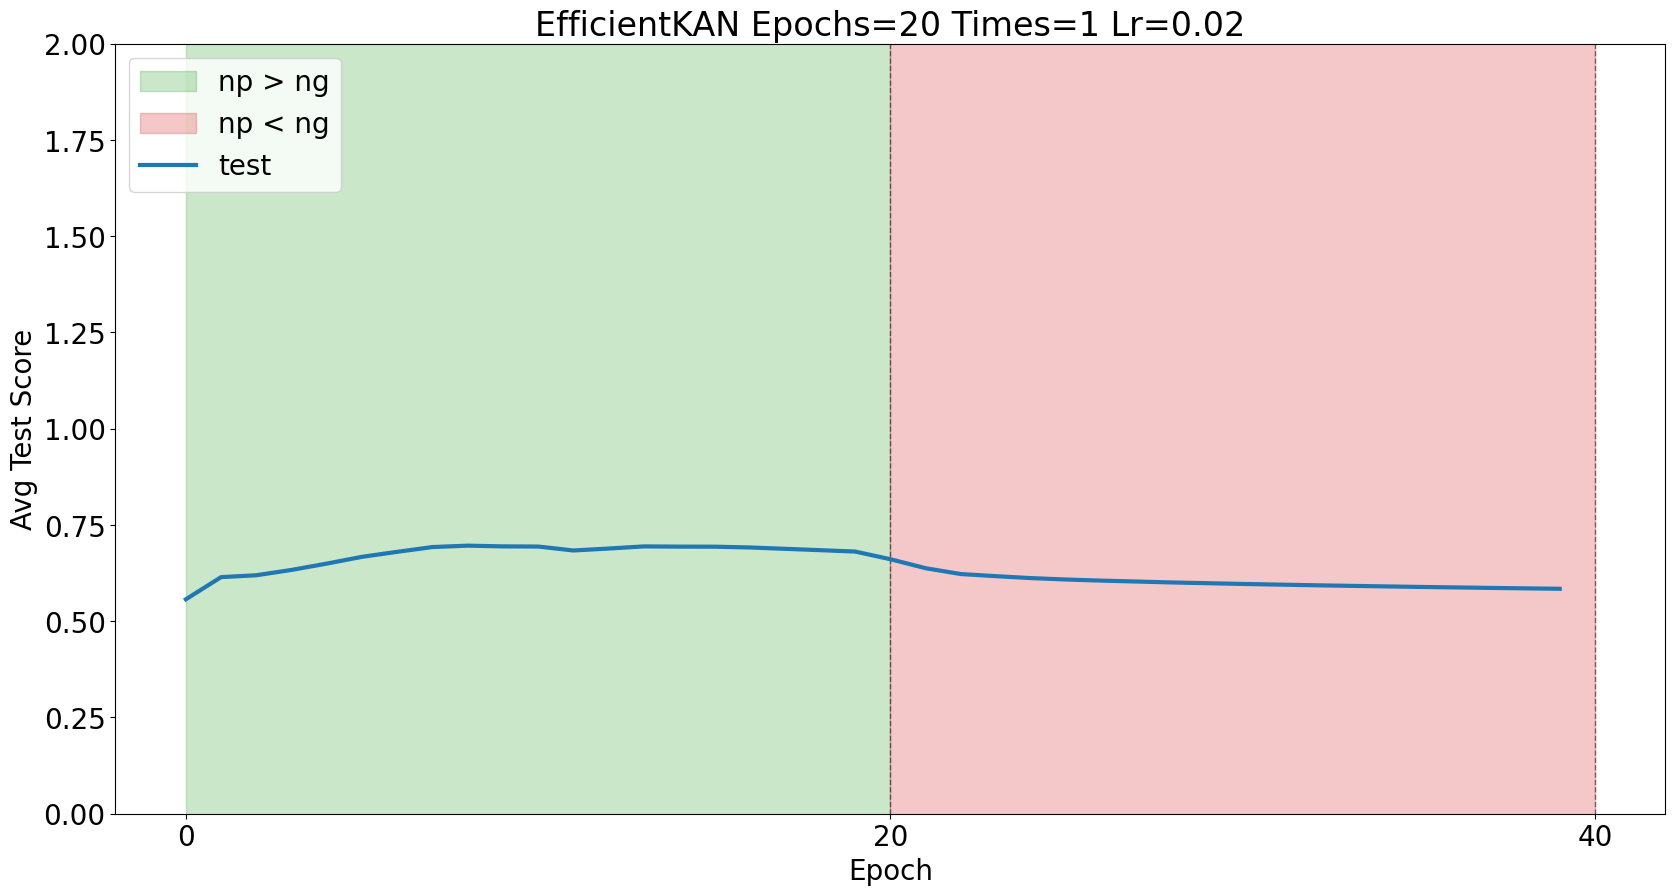

([[0.3393509345395224,
   0.10642057527152318,
   0.07526379386110911,
   0.05999404830592019,
   0.0508451292084323,
   0.04396268719482043,
   0.03906635996249933,
   0.034736602463656,
   0.031579330120058285,
   0.02919376632642178,
   0.02638874613931255,
   0.02328441088043508,
   0.020350561432895205,
   0.01692616207791226,
   0.01440456539155945,
   0.012863278950727175,
   0.011941086493491654,
   0.011787339475833707,
   0.010989320250080219,
   0.010457625797402764],
  [0.11219736149475451,
   0.006753022388909899,
   0.0036570627024278993,
   0.0025717839552459143,
   0.0020279639584404076,
   0.0016918241435344079,
   0.0014537160870589552,
   0.0012772887047114117,
   0.0011443147571602215,
   0.0010392979177321114,
   0.0009525791187086956,
   0.0008798600313076306,
   0.0008178477631493782,
   0.0007649974020693214,
   0.0007194606693542843,
   0.0006797470296511338,
   0.0006445595280392953,
   0.000613142425122316,
   0.0005848903986459066,
   0.0005593948864973047]]

In [58]:
effKAN = EfficientKAN([len(df_x.columns) - 1, 51, 51, 1], 'classification', grid_size=20,
                    use_native_loss=USE_NATIVE_LOSS, continual_learning=True, device='cuda')
idl_train(effKAN, DOMAINS, epochs=EPOCHS, times=TIMES, lr=LR, device='cuda')

# MLP

100%|██████████| 16/16 [00:43<00:00,  2.70s/it]


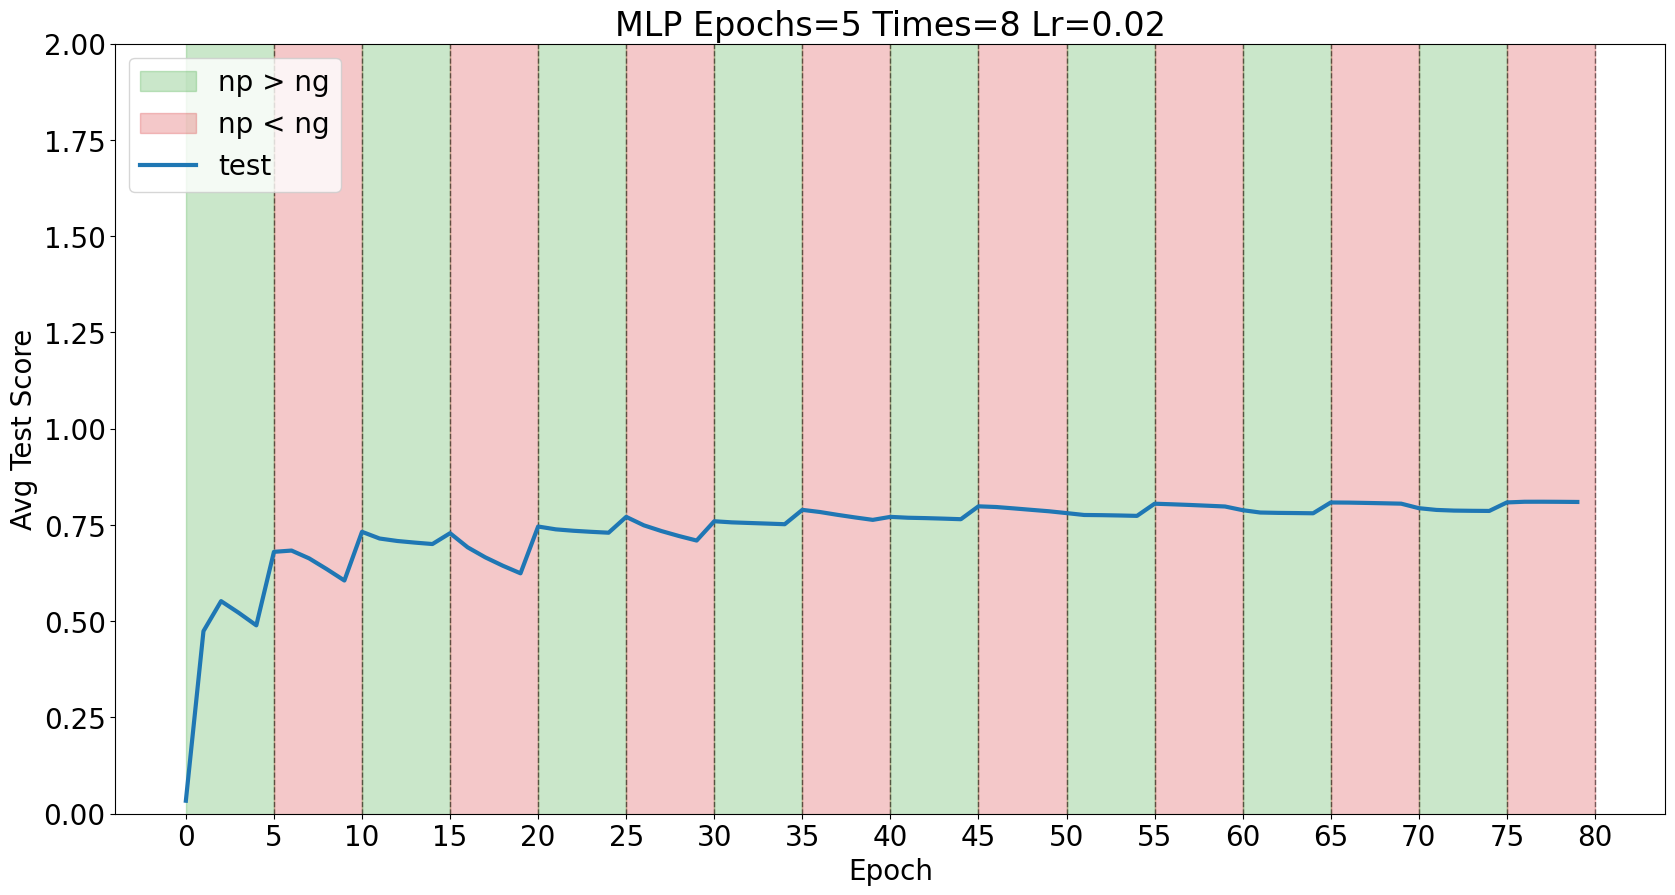

([[0.9448641198022025,
   0.6207039167010595,
   0.35970152417818707,
   0.3221902814176347,
   0.3150684161791726],
  [0.2564908904097383,
   0.03988969654199623,
   0.026610122343140936,
   0.019948784542816973,
   0.01605682462335579],
  [0.46128335122078185,
   0.32007514862787156,
   0.31409982225251576,
   0.3112382893524473,
   0.3091117678180573],
  [0.0997466521544589,
   0.03152345842312253,
   0.02391512090310691,
   0.019364802388563043,
   0.016428270244172642],
  [0.42886655482034836,
   0.31539648723980734,
   0.3109775161932385,
   0.30842580350618515,
   0.3064778518109095],
  [0.08337808787704461,
   0.028406488694368848,
   0.022613079627118414,
   0.019421176230978398,
   0.017265885920515135],
  [0.39063789872896104,
   0.3126761657851083,
   0.30935873587926227,
   0.30703923058888266,
   0.30516271600647576],
  [0.06282403281638546,
   0.025864208738009136,
   0.021819483104442792,
   0.019370303725794194,
   0.01764409520500709],
  [0.36099437967179315,
   0.310

In [11]:
mlp = MLP([len(df_x.columns) - 1, 4, 4, 1], 'classification',
        use_native_loss=USE_NATIVE_LOSS, device='cuda')
idl_train(mlp, DOMAINS, epochs=EPOCHS, times=TIMES, lr=LR, device='cuda')

# Visualize the results with the visualizer GUI

In [13]:
TITLES=['Comparison of different KAN grid sizes','Comparison of different MLP architecture sizes','MLP vs KAN without Replay', 'MLP vs KAN with Replay']
visualizer_gui(metric='avg_test_score', ylim=[0, 1],
               title=TITLES[1])